In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

warnings.filterwarnings("ignore")

In [193]:
df = pd.read_csv("Downloads/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [194]:
df.shape

(1338, 7)

In [195]:
df.size

9366

In [196]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [198]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [199]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [200]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

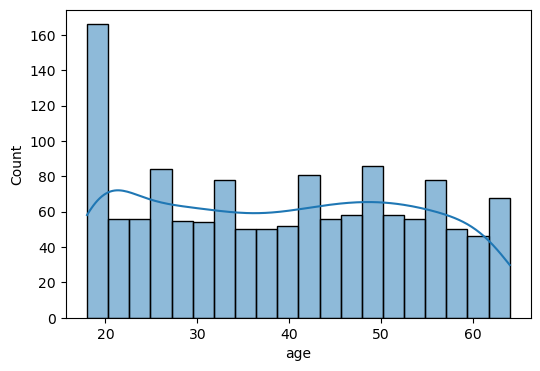

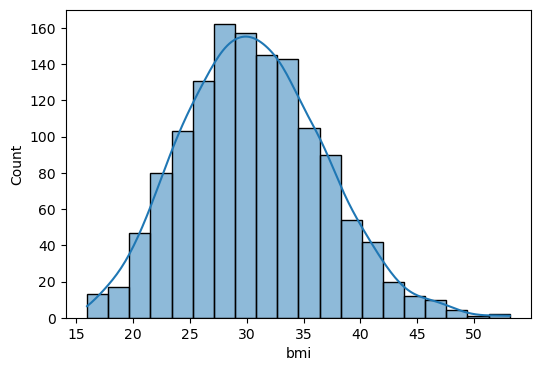

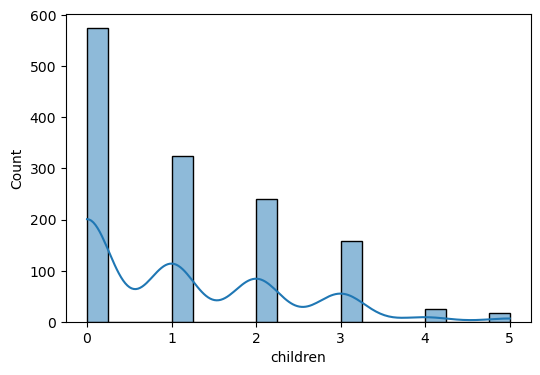

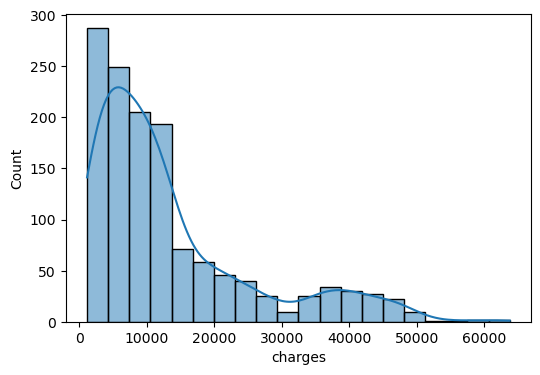

In [201]:
numeric_columns = ['age', 'bmi', 'children','charges']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col] , kde = True , bins = 20)

<Axes: xlabel='children', ylabel='count'>

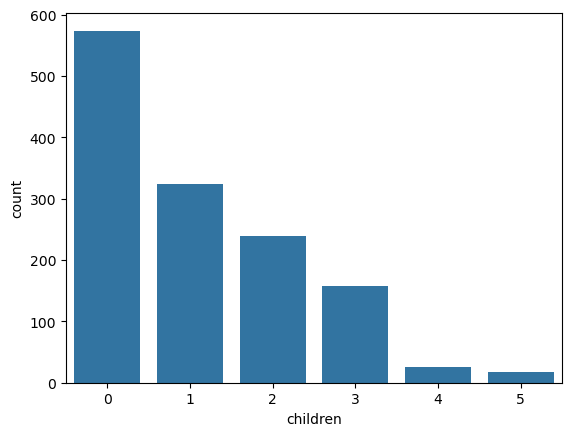

In [202]:
sns.countplot(x = df["children"])

<Axes: xlabel='sex', ylabel='count'>

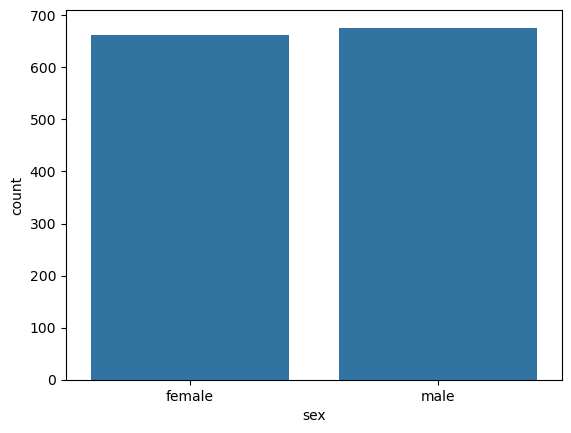

In [203]:
sns.countplot(x = df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

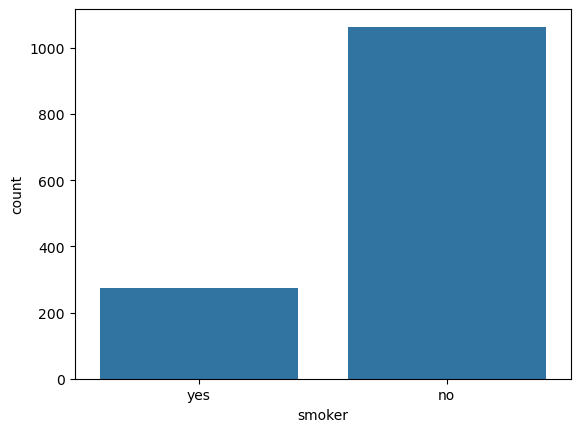

In [204]:
sns.countplot(x = df["smoker"])

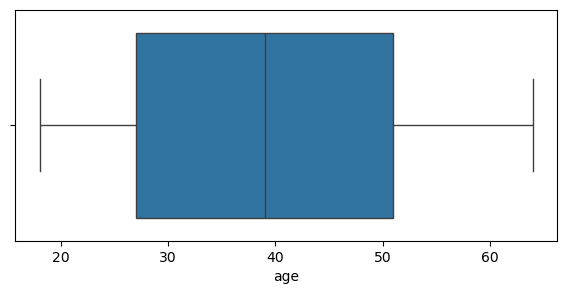

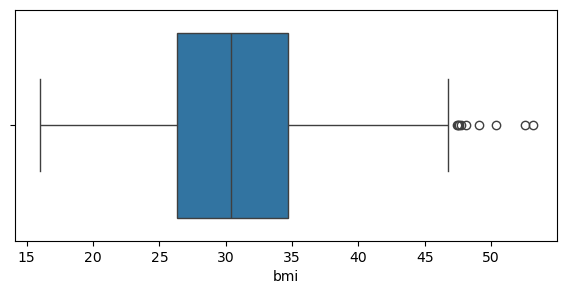

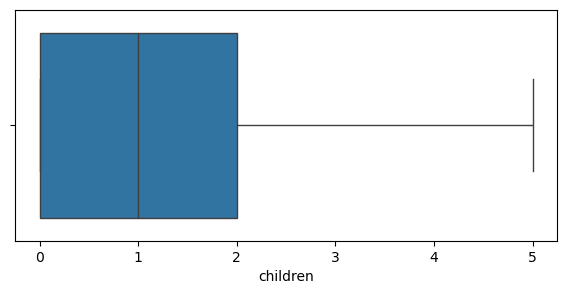

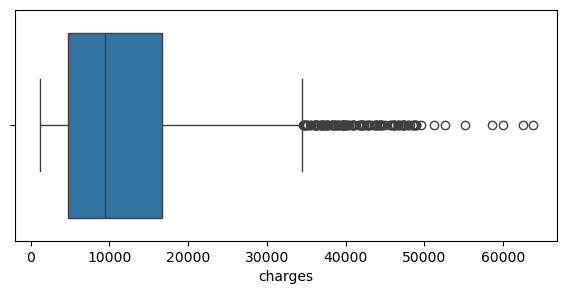

In [205]:
for col in numeric_columns:
    plt.figure(figsize = (7,3))
    sns.boxplot(x = df[col])

<Axes: >

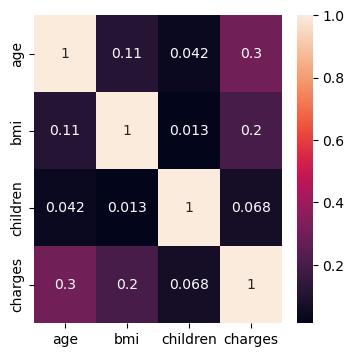

In [206]:
plt.figure(figsize = (4,4))
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [207]:
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [208]:
df.isna().head().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [209]:
df_cleaned.drop_duplicates(inplace =True)

In [210]:
df_cleaned.shape

(1337, 7)

In [211]:
df.shape

(1338, 7)

In [212]:
df_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [213]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [214]:
df_cleaned.value_counts('sex')

sex
male      675
female    662
Name: count, dtype: int64

In [215]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0 , 'female':1})

In [216]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [217]:
df_cleaned.value_counts('smoker')

smoker
no     1063
yes     274
Name: count, dtype: int64

In [218]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0 , 'yes': 1})

In [219]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [220]:
df_cleaned.rename(columns = {
    'sex': 'is_Female',
    'smoker':'is_smoker'} , inplace = True )

In [221]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [222]:
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [223]:
df_cleaned.value_counts('region')

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [225]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['region'] , drop_first = True)

In [226]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [229]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [230]:
# feature extraction and enginnering

In [235]:
df_cleaned['bmi category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9, float('inf')],
    labels=['underweight' , 'normal' , 'overweight' , 'obese']
)

In [236]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [237]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['bmi category'] , drop_first =  True)

In [238]:
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [239]:
df_cleaned.astype(int)

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [240]:
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [241]:
df_cleaned.astype(int).head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [242]:
df_cleaned.columns

Index(['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'],
      dtype='object')

In [247]:
from sklearn.preprocessing import StandardScaler
cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [248]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,False,False,True
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,False,False,True
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,False,False,True
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,False,True,False


In [251]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_Female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_Female,-0.058046
8,bmi category_normal,-0.104042


In [252]:
cat_features = [
    'is_Female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'
]

In [253]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_Female,10.258784,0.01649,Reject Null (Keep Feature)
bmi category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi category_overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi category_normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [254]:
final_df = df_cleaned[['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi category_obese']]

In [255]:
final_df

,age,is_Female,bmi,children,is_smoker,charges,region_southeast,bmi category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,False
1,-1.511647,0,0.462463,-0.079442,0,1725,1,True
2,-0.799350,0,0.462463,1.580143,0,4449,1,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,False
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,True
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,True
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,True
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,False
